### Astrostatistics lecture 11

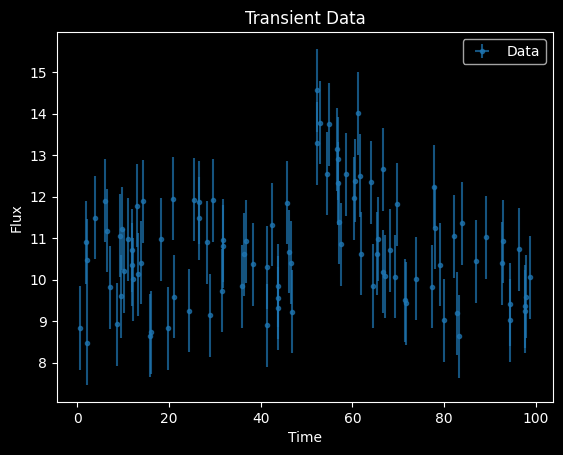

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import stats
import emcee
import corner
from sklearn.neighbors import KernelDensity
import matplotlib.patches as mpatches
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

data = np.load('/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/transient.npy') #load data
time = data[:,0]
flux = data[:,1]
errors = np.ones_like(flux)

plt.errorbar(time, flux, errors, 0,  '.', alpha = 0.7, label = 'Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.title('Transient Data')
plt.show()

In [8]:
def model(A, b, t, t0, alfa):   #define the model to use
    return np.where(t < t0, b, b + A * np.exp(-alfa*(t - t0)))

def log_prior(theta):   #define the prior, in this case a uniform one with define ranges for the parameters
    A, b, t0, log_alfa = theta      #can be done also as priorA*priorB*... but this is faster and works the same way
    if 0 < A < 50 and 0 < b < 50 and 0 < t0 < 100 and -5 < log_alfa < 5:
        return -log_alfa
    return -np.inf  #if it's in the limit the prior is 0 otherwise it's -inf

def log_likelihood(theta, t, data, errors):     #log of a gaussian likelihood
    A, b, t0, log_alfa = theta
    alfa = np.exp(log_alfa)
    m = model(A, b, t, t0, alfa)    #likelihood of the model given the data we have and the errors (equal but whatever)
    return -0.5 * np.sum((data - m)**2 / errors**2)

def log_posterior(theta, t, data, errors):      #our posterior is the product of the likelihood and the prior (all in log)
    return log_prior(theta) + log_likelihood(theta, t, data, errors)

In [20]:
ndim, nwalkers = 4, 20  #20 walkers on 4D parameter space
initial = np.array([5, 10, 50, 0]) #initial values guess (middle point of the prior range)
pos = initial + 1e-1 * np.random.randn(nwalkers, ndim)  #random initial positions
nsteps = 10000  #number of MCMC steps

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(time, flux, errors))   #MCMC sampler given the posterior and the arguments
sampler.run_mcmc(pos, nsteps);     #run the MCMC


/tmp/ipykernel_6900/2639061994.py:2: RuntimeWarning: overflow encountered in exp
  return np.where(t < t0, b, b + A * np.exp(-alfa*(t - t0)))


(20, 10000, 4)


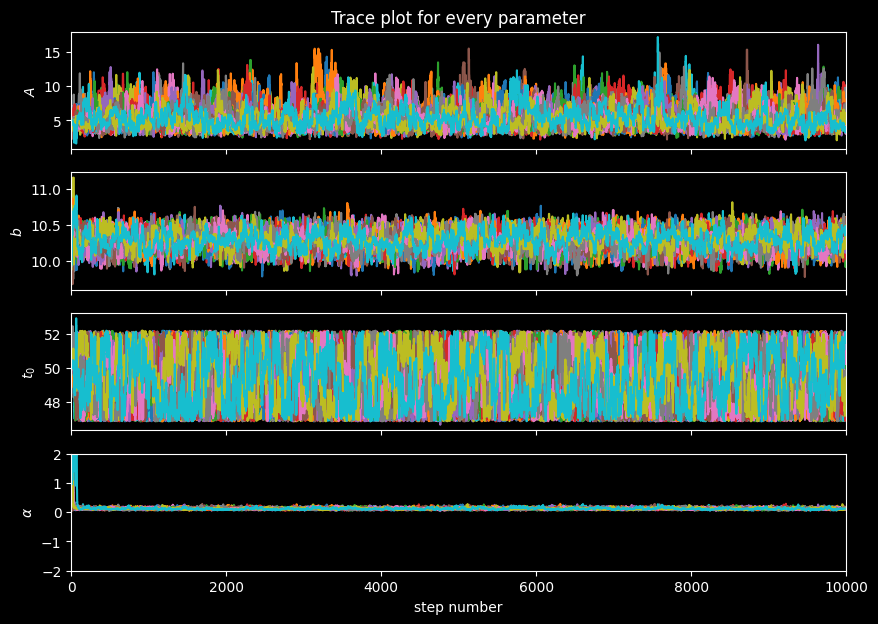

In [47]:
print(sampler.chain.shape) #original chain size

#take the trace plot to see what burning to apply
raw_samples = sampler.get_chain()
    #real values of alpha not the log
samples = raw_samples.copy()
samples[:, :, 3] = np.exp(raw_samples[:, :, 3])


fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
labels = ["$A$", "$b$", "$t_0$", "$\\alpha$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i])
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
axes[3].set_ylim(-2, 2)


axes[0].set_title('Trace plot for every parameter')

axes[-1].set_xlabel("step number");



[75.00544174 51.65879019 68.08589294 53.73175029]
(2360, 4)


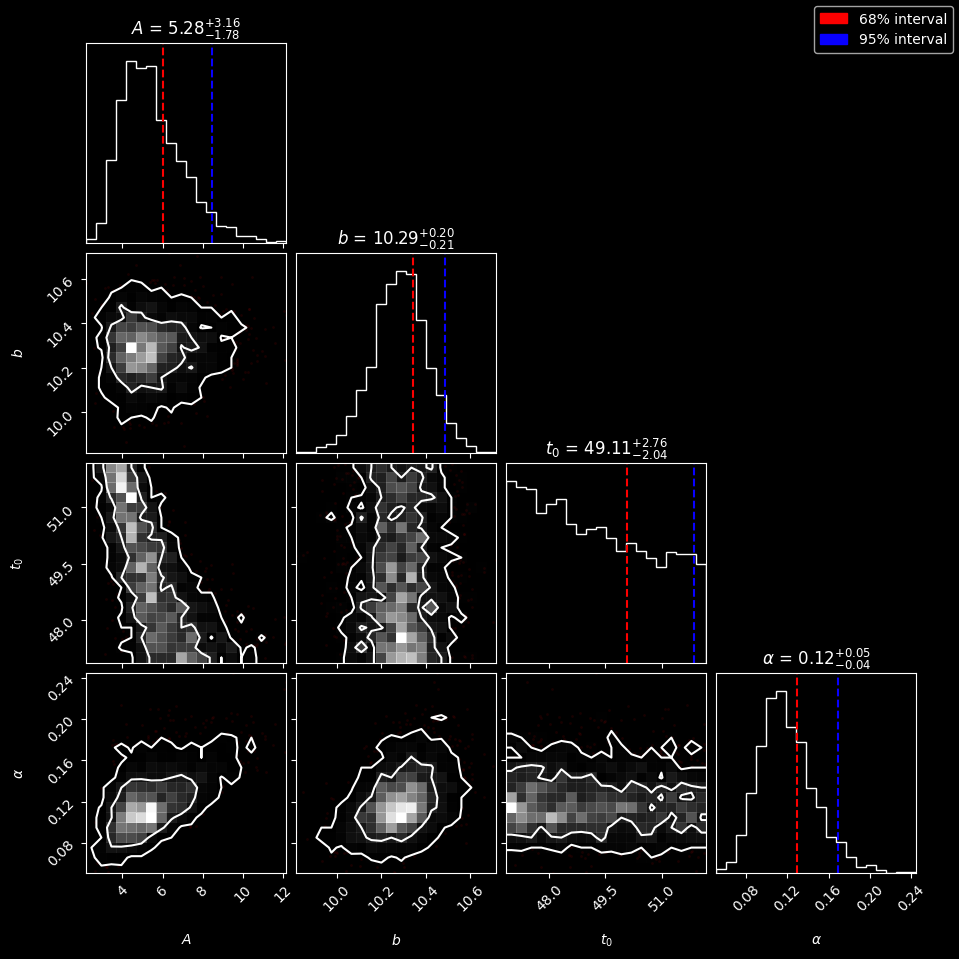

In [48]:
tau = sampler.get_autocorr_time()
print(tau)
burn = 1000 #that's a safe time to cut the initial transient phase
thin = int(max(tau)+1)
raw_flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)    #burn and thin the chain

flat_samples = raw_flat_samples.copy()
flat_samples[:, 3] = np.exp(raw_flat_samples[:, 3])
print(flat_samples.shape)   #final chain size

#corner plot of the marginalized distributions of the 4 parameters
fig = corner.corner(flat_samples, labels=labels, figsize=(10, 10),  quantiles=[0.68, 0.95], title_quantiles=[0.05, 0.5, 0.95], levels=(0.68, 0.95), show_titles=True)
colors=["#FC0000", "#0800FF"]       #in the title we write the +- for the 68% not both 68 and 95

for ax in fig.axes:     #needs this to have different color on the quantiles
    for i, line in enumerate(ax.lines):
        line.set_color(colors[i % len(colors)])
        line.set_linewidth(1.5)

#custom legend for the quantiles colors
legend_patch = [
    mpatches.Patch(color=colors[0], label="68% interval"),
    mpatches.Patch(color=colors[1], label="95% interval"),
]

fig.legend(handles=legend_patch, loc="upper right")

plt.show()

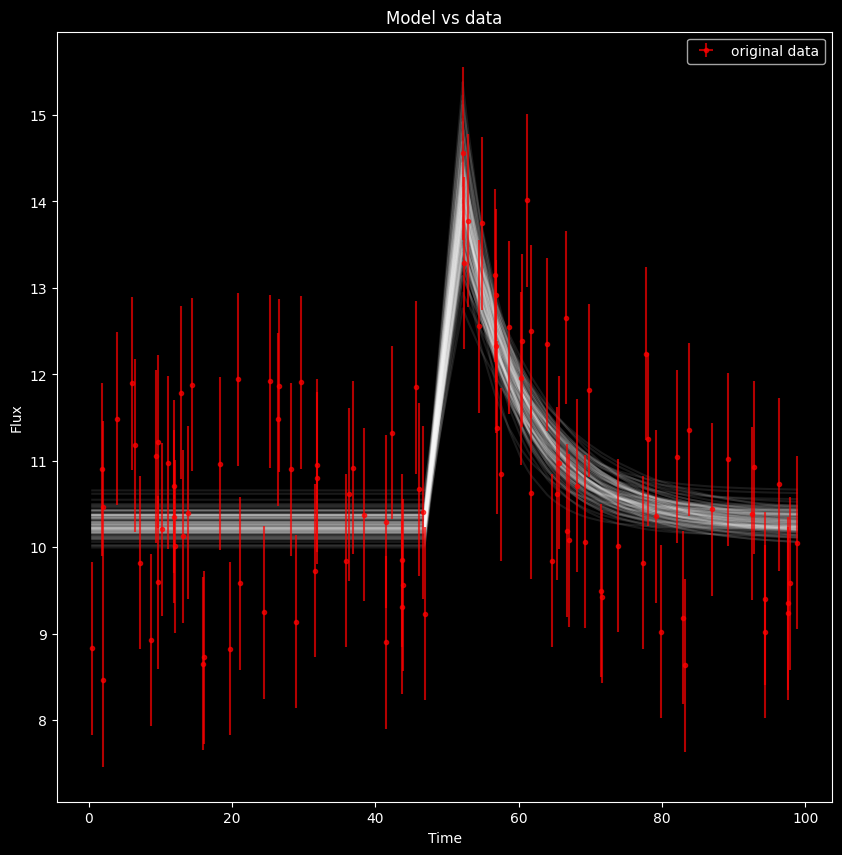

In [50]:
# now we randomly pick 100 values from out burned and thinned array and confront them with the original data 
plt.figure(figsize=(10, 10))

#usually called posterior predictive checks
random_sample = flat_samples[np.random.randint(len(flat_samples), size=100)]
for i in range(len(random_sample)):     #for every random sample of parameters we evaluate the model and confront them with the data
    modello = model(random_sample[i][0], random_sample[i][1], time, random_sample[i][2], random_sample[i][3])   #plot every model
    plt.plot(time, modello, color='white', alpha=0.1)

plt.errorbar(time, flux, errors, 0,  '.', alpha = 0.7, label = 'original data', color='red')    #plot original data
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.title('Model vs data')
plt.show()

In [51]:
#finally for each parameter we find the median and 90% credible region of the marginalized distribution (basically the corner plot titles)
from IPython.display import display, Math

def show_param(name, m, l, u):
    plus = u - m
    minus = m - l
    
    display(Math(
        rf"{name} = {m:.3f}^{{+{plus:.3f}}}_{{-{minus:.3f}}}"
    ))

labels = ["A", "b", r"t_0", r"\alpha"]
for i in range(ndim):
    m = float(np.median(flat_samples[:, i]))
    l = float(np.percentile(flat_samples[:, i], 5))
    u = float(np.percentile(flat_samples[:, i], 95))
    if i<3:
        show_param(labels[i], m, l, u)
    else:
        show_param(labels[i], np.exp(m), np.exp(l), np.exp(u))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>